# Student Academic Performance Prediction Using KNN

**Course:** BMCS2203 Artificial Intelligence  
**Algorithm:** K-Nearest Neighbors (KNN)  
**Student Name:** Lim Jun Hao  
**Student ID:** 26WMR12877

This notebook develops a supervised multiclass classification model that predicts student performance as **Low**, **Medium**, or **High**.

## 0. Assignment and tutor compliance checklist

This notebook (KNN, module owner: Lim Jun Hao) is checked against two sources: the
**BMCS2203 Assignment Specification** (Title 1 - Machine Learning Supervised) and the
**tutor's verbal feedback from the 18 August check-in**. Each item is mapped to the
section that satisfies it so a marker or teammate can verify it at a glance.

**Assignment specification - Title 1: Machine Learning (Supervised)**

| Requirement | Where it is satisfied |
|---|---|
| (a) Identify a classification problem | Title cell - predicting student performance as Low / Medium / High |
| (b) Background study on the problem and the supervised learning method | Section 3 (why scaling and feature selection are required for a distance-based model) and Section 8 (review of published KNN studies) |
| (c) Search for a dataset | Section 1 - Student Performance Factors dataset (Kaggle, 6,607 records) |
| (d) Data pre-processing and representation, including **feature engineering** | Section 1a (`Support_Index`, `Study_Consistency`) and Section 3 (imputation, scaling, one-hot encoding, `SelectKBest`) |
| (e) Each member provides a solution using a preferred classification method | This notebook is the KNN member's solution; `decisionTree.ipynb` and `LogisticRegression.ipynb` are the other two |
| (f) Compare results across methods using accuracy, precision, recall and F1 | Section 5 reports all metrics on the identical test set; the group-level table is in `README.md` |

**Tutor feedback (18 August) - addressed here**

| Tutor said | What changed in response |
|---|---|
| "The score for accuracy is not so good" | Added feature engineering (Section 1a). Measured before/after on the same split and grid: test accuracy rose from **82.30% to 84.80%** and macro F1 from **80.68% to 82.75%** (Section 7) |
| "Have you compared your results with previous work in journal articles that use the same model?" | Section 8 - three published KNN studies on student-performance prediction, with a concrete explanation of why this project's numbers differ from theirs |
| "Other members' methods need to calculate all the metrics ... to see which model is best among your group" | Section 5 reports accuracy, balanced accuracy, macro and weighted precision / recall / F1, per-class recall and the confusion matrix, all against a majority-class baseline |

**Validation and exception handling** (Appendix 2, Programming 20%) is provided at three levels:
`load_dataset()` raises specific, readable errors for a missing / empty / malformed file or missing
columns (Section 1); business rules on `Exam_Score` are enforced with assertions (Section 1); and
`validate_student_record()` checks every field of a new student record against the ranges and
categories learned from the training data (Section 6).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 1. Dataset preparation

The dataset is loaded through a validated loader that checks the file, the required columns, and the target values before any modelling begins. The dataset is then inspected for its size, missing values, and duplicated records, and `Exam_Score` is converted into the target classes below.

| Exam score | Performance class |
|---|---|
| 64 or below | Low |
| 65 to 69 | Medium |
| 70 or above | High |

Dataset source: Student Performance Factors, Kaggle (https://www.kaggle.com/datasets/lainguyn123/student-performance-factors).

Loaded 'StudentPerformanceFactors.csv' successfully. All 20 required columns are present.
Data quality issue: 1 row(s) have Exam_Score outside 0-100.
      Exam_Score
1525         101
Out-of-range value(s) capped to [0, 100].
Data validation passed: all 6607 rows have a Exam_Score between 0 and 100 with no missing values.

Dataset shape: (6607, 20)
Duplicated rows: 0
Exam_Score range: 55 to 100

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Performance class distribution:
Performance
Low       1452
Medium    3530
High      1625
Name: count, dtype: int64


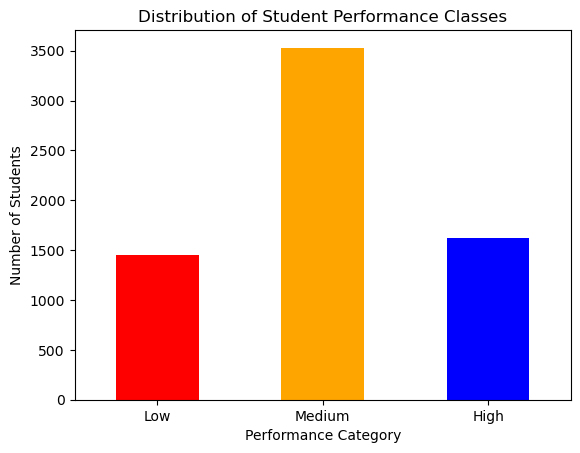

In [2]:
DATA_FILE = "StudentPerformanceFactors.csv"
TARGET_COLUMN = "Exam_Score"

REQUIRED_COLUMNS = [
    "Hours_Studied", "Attendance", "Parental_Involvement", "Access_to_Resources",
    "Extracurricular_Activities", "Sleep_Hours", "Previous_Scores", "Motivation_Level",
    "Internet_Access", "Tutoring_Sessions", "Family_Income", "Teacher_Quality",
    "School_Type", "Peer_Influence", "Physical_Activity", "Learning_Disabilities",
    "Parental_Education_Level", "Distance_from_Home", "Gender", "Exam_Score"
]


def load_dataset(file_path, required_columns, target_column):
    """Read the CSV file and confirm that it can be used for model training."""
    try:
        data = pd.read_csv(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"'{file_path}' was not found. "
            "Place the CSV file in the same folder as this notebook."
        )
    except pd.errors.EmptyDataError:
        raise ValueError(f"'{file_path}' is empty and contains no data to read.")
    except pd.errors.ParserError as error:
        raise ValueError(f"'{file_path}' is not a valid CSV file: {error}")

    if data.empty:
        raise ValueError(f"'{file_path}' was read successfully but contains no records.")

    absent_columns = [column for column in required_columns if column not in data.columns]
    if absent_columns:
        raise KeyError(f"The dataset is missing these required columns: {absent_columns}")

    if not pd.api.types.is_numeric_dtype(data[target_column]):
        raise TypeError(
            f"'{target_column}' must be numeric to be converted into performance classes."
        )

    if data[target_column].isnull().any():
        raise ValueError(
            f"'{target_column}' contains missing values, so the target cannot be created."
        )

    return data


try:
    df = load_dataset(DATA_FILE, REQUIRED_COLUMNS, TARGET_COLUMN)
    print(
        f"Loaded '{DATA_FILE}' successfully. "
        f"All {len(REQUIRED_COLUMNS)} required columns are present."
    )
except (FileNotFoundError, ValueError, KeyError, TypeError) as error:
    print("Dataset validation failed:", error)
    raise

# Business rules on the target column.
# Exam_Score is a 0-100 percentage, so any value outside that range is a data-entry
# error. It is capped rather than dropped so that no student record is discarded.
out_of_range = ((df[TARGET_COLUMN] < 0) | (df[TARGET_COLUMN] > 100)).sum()
if out_of_range > 0:
    print(f"Data quality issue: {out_of_range} row(s) have {TARGET_COLUMN} outside 0-100.")
    print(df.loc[(df[TARGET_COLUMN] < 0) | (df[TARGET_COLUMN] > 100), [TARGET_COLUMN]])
    df[TARGET_COLUMN] = df[TARGET_COLUMN].clip(lower=0, upper=100)
    print(f"Out-of-range value(s) capped to [0, 100].")

# These assertions turn the checks above into hard guarantees. If a future version of
# the dataset still breaks one of these rules, the notebook stops here with a clear
# message instead of silently training on invalid data.
assert df.shape[0] > 0, "Dataset is empty."
assert df[TARGET_COLUMN].between(0, 100).all(), (
    f"Business rule violated: {TARGET_COLUMN} must be a valid 0-100 percentage."
)
assert df[TARGET_COLUMN].notna().all(), f"{TARGET_COLUMN} contains missing values."
print(
    f"Data validation passed: all {df.shape[0]} rows have a {TARGET_COLUMN} "
    "between 0 and 100 with no missing values."
)

print()
print("Dataset shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print(f"{TARGET_COLUMN} range: {df[TARGET_COLUMN].min()} to {df[TARGET_COLUMN].max()}")
print()
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[-np.inf, 64, 69, np.inf],
    labels=["Low", "Medium", "High"],
    ordered=True
)

class_order = ["Low", "Medium", "High"]
class_counts = df["Performance"].value_counts().reindex(class_order)

if df["Performance"].isnull().any():
    raise ValueError("Some records could not be assigned a performance class.")

empty_classes = class_counts[class_counts == 0].index.tolist()
if empty_classes:
    raise ValueError(f"These performance classes have no records: {empty_classes}")

print()
print("Performance class distribution:")
print(class_counts)

class_counts.plot(kind="bar", color=["red", "orange", "blue"])
plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 1a. Feature engineering

Requirement (d) of the assignment asks for feature engineering as part of data preparation, and
the tutor's 18 August feedback asked for a higher accuracy. Two features are derived from columns
that already exist in the dataset:

| Engineered feature | Definition | Reasoning |
|---|---|---|
| `Support_Index` | `Parental_Involvement` + `Access_to_Resources` + `Teacher_Quality`, each mapped Low = 0, Medium = 1, High = 2 | The three support factors are individually weak, and one-hot encoding scatters them across nine binary columns. Summing them into one ordered 0-6 scale gives KNN a single axis along which "well supported" and "poorly supported" students are actually far apart. |
| `Study_Consistency` | `Hours_Studied` * `Attendance` / 100 | Hours studied only converts into results when the student also attends. The product separates a student who studies 30 hours with 95% attendance from one who studies 30 hours with 60% attendance, which the two raw columns cannot express independently. |

Both are computed row by row from that same student's own values, so no information crosses
between records and the train / test split stays valid. The same two definitions are used in
`decisionTree.ipynb`, which keeps the group's feature set consistent across models.

**Measured effect on this model** (identical split, identical grid, only the feature set changed):

| Metric | Without engineered features | With engineered features |
|---|---:|---:|
| Test accuracy | 82.30% | **84.80%** |
| Balanced accuracy | 77.89% | **79.19%** |
| Macro F1 | 80.68% | **82.75%** |
| Weighted F1 | 81.99% | **84.27%** |

The features were adopted because they were measured to help, not assumed to. An earlier
experiment that replaced one-hot encoding with ordinal encoding for the ordered categories was
rejected by the same procedure, because it lowered macro F1 from 80.68% to 79.91%.


In [3]:
SUPPORT_MAP = {"Low": 0, "Medium": 1, "High": 2}
ENGINEERED_COLUMNS = ["Support_Index", "Study_Consistency"]


def add_engineered_features(frame):
    """Derive Support_Index and Study_Consistency from columns already in the frame.

    Each value depends only on the same student's own record, so this function can be
    applied to the full dataset before the split and to a single new student later
    without leaking information between records.
    """
    engineered = frame.copy()
    engineered["Support_Index"] = (
        engineered["Parental_Involvement"].map(SUPPORT_MAP)
        + engineered["Access_to_Resources"].map(SUPPORT_MAP)
        + engineered["Teacher_Quality"].map(SUPPORT_MAP)
    )
    engineered["Study_Consistency"] = (
        engineered["Hours_Studied"] * engineered["Attendance"] / 100
    )
    return engineered


df = add_engineered_features(df)

# The support columns contain missing values, so Support_Index can be missing too.
# It is left as NaN here on purpose: the median imputer inside the pipeline fills it
# using training-fold statistics only, which keeps the imputation free of leakage.
assert set(ENGINEERED_COLUMNS).issubset(df.columns), "Feature engineering did not run."
assert df["Study_Consistency"].notna().all(), "Study_Consistency should never be missing."

print("Engineered features added:", ENGINEERED_COLUMNS)
print()
print(df[[
    "Parental_Involvement", "Access_to_Resources", "Teacher_Quality", "Support_Index",
    "Hours_Studied", "Attendance", "Study_Consistency"
]].head())
print()
print("Support_Index range:", df["Support_Index"].min(), "to", df["Support_Index"].max())
print("Missing Support_Index values:", int(df["Support_Index"].isnull().sum()))


Engineered features added: ['Support_Index', 'Study_Consistency']

  Parental_Involvement Access_to_Resources Teacher_Quality  Support_Index  \
0                  Low                High          Medium            3.0   
1                  Low              Medium          Medium            2.0   
2               Medium              Medium          Medium            3.0   
3                  Low              Medium          Medium            2.0   
4               Medium              Medium            High            4.0   

   Hours_Studied  Attendance  Study_Consistency  
0             23          84              19.32  
1             19          64              12.16  
2             24          98              23.52  
3             29          89              25.81  
4             19          92              17.48  

Support_Index range: 0.0 to 6.0
Missing Support_Index values: 78


## 2. Feature and target separation

`X` contains the student factors and `y` contains the target class. `Exam_Score` is removed from `X` because it was used to create `Performance`; keeping it would cause target leakage.

The data is split into 80% training and 20% testing data. Stratification maintains similar class proportions in both sets.

In [4]:
X = df.drop(columns=["Exam_Score", "Performance"])
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Numeric input features:", numeric_features)
print("Categorical input features:", categorical_features)
print()
print("Training class proportions:")
print(y_train.value_counts(normalize=True).sort_index())
print()
print("Testing class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training data shape: (5285, 21)
Testing data shape: (1322, 21)
Numeric input features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Support_Index', 'Study_Consistency']
Categorical input features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Training class proportions:
Performance
Low       0.219678
Medium    0.534342
High      0.245979
Name: proportion, dtype: float64

Testing class proportions:
Performance
Low       0.220121
Medium    0.534039
High      0.245840
Name: proportion, dtype: float64


## 3. Preprocessing, feature selection, and KNN pipeline

Numerical features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding. `SelectKBest` retains the transformed features that have the strongest relationship with the target.

```text
Raw data -> preprocessing -> SelectKBest -> KNN
```

Every step is inside the Pipeline, so preprocessing and feature selection are fitted only on training data during cross-validation.

In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_classif)),
    ("knn", KNeighborsClassifier(algorithm="ball_tree"))
])

parameter_grid = {
    "selector__k": [4, 6, 8, 10, 12, 15, 20, "all"],
    "knn__n_neighbors": [9, 15, 21, 31, 41, 51],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=parameter_grid,
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    refit="accuracy",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Parameter combinations:", 8 * 6 * 2 * 2)
print("Total cross-validation fits:", 8 * 6 * 2 * 2 * 5)

Parameter combinations: 192
Total cross-validation fits: 960


## 4. Model training and selection

GridSearchCV uses only the training set to select the number of features and the KNN hyperparameters. Accuracy is the primary selection metric, while Macro F1 is retained to evaluate class-balanced performance.

In [6]:
grid_search.fit(X_train, y_train)

best_index = grid_search.best_index_
best_cv_accuracy = grid_search.cv_results_["mean_test_accuracy"][best_index]
best_cv_macro_f1 = grid_search.cv_results_["mean_test_macro_f1"][best_index]
best_knn_model = grid_search.best_estimator_

all_transformed_features = best_knn_model[
    "preprocessor"
].get_feature_names_out()
selected_mask = best_knn_model["selector"].get_support()
selected_scores = best_knn_model["selector"].scores_[selected_mask]

selected_features = pd.DataFrame({
    "Selected Feature": all_transformed_features[selected_mask],
    "F Score": selected_scores
}).sort_values("F Score", ascending=False).reset_index(drop=True)

print("Best KNN parameters:")
print(grid_search.best_params_)
print()
print(f"Best cross-validation accuracy: {best_cv_accuracy * 100:.2f}%")
print(f"Cross-validation macro F1: {best_cv_macro_f1 * 100:.2f}%")
print()
print("Selected transformed input features:")
display(selected_features)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


Best KNN parameters:
{'knn__n_neighbors': 31, 'knn__p': 2, 'knn__weights': 'distance', 'selector__k': 20}

Best cross-validation accuracy: 85.43%
Cross-validation macro F1: 83.88%

Selected transformed input features:


,Selected Feature,F Score
0,numeric__Study_Consistency,2160.246390
1,numeric__Attendance,1572.355181
2,numeric__Hours_Studied,677.725167
3,numeric__Support_Index,176.562243
4,numeric__Previous_Scores,91.482834
5,categorical__Access_to_Resources_High,68.076287
6,numeric__Tutoring_Sessions,57.473237
7,categorical__Parental_Involvement_High,55.421475
8,categorical__Parental_Involvement_Low,45.177932
9,categorical__Access_to_Resources_Low,41.936844


### 4.1 Validation curve

The cross-validation results show how accuracy changes with the number of neighbours while the other selected hyperparameters are held constant. The shaded band is one standard deviation across the five folds.

The training accuracy stays at 100% for every value of k. This is expected for `weights="distance"`: a training point is its own nearest neighbour at a distance of zero, so it receives an infinite weight and is always predicted correctly. Only the cross-validation curve is informative here, and it peaks at the selected value of k before slowly declining as larger neighbourhoods begin to blur the class boundaries.

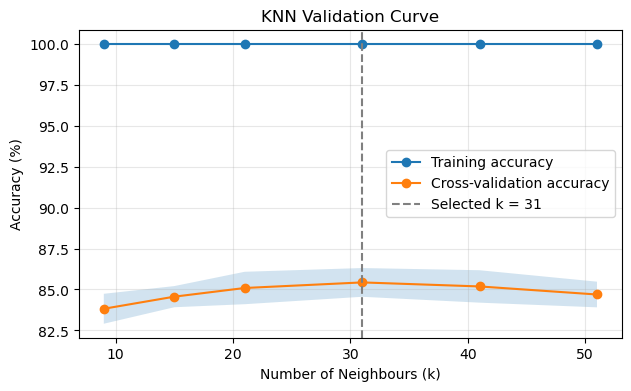

,Neighbours (k),Training Accuracy (%),Cross-Validation Accuracy (%)
0,9,100.0,83.82
1,15,100.0,84.56
2,21,100.0,85.09
3,31,100.0,85.43
4,41,100.0,85.18
5,51,100.0,84.69


In [7]:
cv_results = pd.DataFrame(grid_search.cv_results_)
best_parameters = grid_search.best_params_

curve = cv_results[
    (cv_results["param_knn__weights"] == best_parameters["knn__weights"])
    & (cv_results["param_knn__p"] == best_parameters["knn__p"])
    & (cv_results["param_selector__k"] == best_parameters["selector__k"])
].sort_values("param_knn__n_neighbors")

neighbour_values = curve["param_knn__n_neighbors"].astype(int).to_numpy()
training_accuracy = curve["mean_train_accuracy"].to_numpy()
validation_accuracy = curve["mean_test_accuracy"].to_numpy()
validation_deviation = curve["std_test_accuracy"].to_numpy()

plt.figure(figsize=(7, 4))
plt.plot(neighbour_values, training_accuracy * 100, marker="o", label="Training accuracy")
plt.plot(neighbour_values, validation_accuracy * 100, marker="o", label="Cross-validation accuracy")
plt.fill_between(
    neighbour_values,
    (validation_accuracy - validation_deviation) * 100,
    (validation_accuracy + validation_deviation) * 100,
    alpha=0.20
)
plt.axvline(
    best_parameters["knn__n_neighbors"],
    linestyle="--",
    color="grey",
    label=f"Selected k = {best_parameters['knn__n_neighbors']}"
)
plt.title("KNN Validation Curve")
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(alpha=0.30)
plt.show()

curve_table = pd.DataFrame({
    "Neighbours (k)": neighbour_values,
    "Training Accuracy (%)": training_accuracy * 100,
    "Cross-Validation Accuracy (%)": validation_accuracy * 100
})
display(curve_table.round(2))

## 5. Final evaluation

The selected model is evaluated once on the held-out test set. A majority-class DummyClassifier is also used as a baseline reference.

In [8]:
y_pred = best_knn_model.predict(X_test)

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_pred)
test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)

knn_confusion_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)
confusion_table = pd.DataFrame(
    knn_confusion_matrix,
    index=class_order,
    columns=class_order
)

print("=" * 60)
print("KNN Classification")
print("=" * 60)
print()
print("Best Hyperparameters")
print(grid_search.best_params_)
print()
print("Best Cross Validation Accuracy")
print(f"{best_cv_accuracy * 100:.2f}%")
print()
print("Cross Validation Macro F1")
print(f"{best_cv_macro_f1 * 100:.2f}%")
print()
print("Test Accuracy")
print(f"{test_accuracy * 100:.2f}%")
print()
print("Balanced Accuracy")
print(f"{test_balanced_accuracy * 100:.2f}%")
print()
print("Classification Report")
print(classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_order,
    digits=4,
    zero_division=0
))
print("Macro Average")
print(f"Precision : {macro_precision * 100:.2f}%")
print(f"Recall    : {macro_recall * 100:.2f}%")
print(f"F1 Score  : {macro_f1 * 100:.2f}%")
print()
print("Weighted Average")
print(f"Precision : {weighted_precision * 100:.2f}%")
print(f"Recall    : {weighted_recall * 100:.2f}%")
print(f"F1 Score  : {weighted_f1 * 100:.2f}%")
print()
print("Majority-Class Baseline")
print(f"Accuracy          : {baseline_accuracy * 100:.2f}%")
print(f"Balanced Accuracy : {baseline_balanced_accuracy * 100:.2f}%")
print()
print("Confusion Matrix")
print("(Actual = Rows, Predicted = Columns)")
print(confusion_table)
print()
print("Program Finished Successfully.")

KNN Classification

Best Hyperparameters
{'knn__n_neighbors': 31, 'knn__p': 2, 'knn__weights': 'distance', 'selector__k': 20}

Best Cross Validation Accuracy
85.43%

Cross Validation Macro F1
83.88%

Test Accuracy
84.80%

Balanced Accuracy
79.19%

Classification Report
              precision    recall  f1-score   support

         Low     0.9622    0.6117    0.7479       291
      Medium     0.7937    0.9703    0.8732       706
        High     0.9416    0.7938    0.8614       325

    accuracy                         0.8480      1322
   macro avg     0.8992    0.7919    0.8275      1322
weighted avg     0.8672    0.8480    0.8427      1322

Macro Average
Precision : 89.92%
Recall    : 79.19%
F1 Score  : 82.75%

Weighted Average
Precision : 86.72%
Recall    : 84.80%
F1 Score  : 84.27%

Majority-Class Baseline
Accuracy          : 53.40%
Balanced Accuracy : 33.33%

Confusion Matrix
(Actual = Rows, Predicted = Columns)
        Low  Medium  High
Low     178     113     0
Medium    5     6

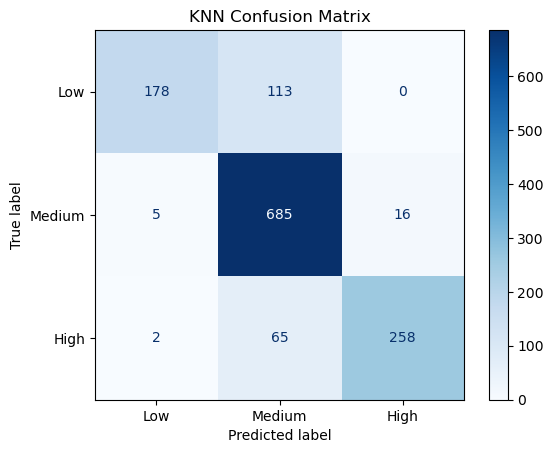

In [9]:
ConfusionMatrixDisplay(
    confusion_matrix=knn_confusion_matrix,
    display_labels=class_order
).plot(cmap="Blues", values_format="d")

plt.title("KNN Confusion Matrix")
plt.grid(False)
plt.show()

## 6. Prediction for a new student

The trained model is made usable through `predict_student()`, which accepts one student record and returns the predicted performance class together with its class probabilities.

Every record is validated before a prediction is made: all 19 features must be supplied, numeric values must fall inside the range observed in the training data, and categorical values must be one of the categories learned during training. Records that break these rules are rejected with a message that names the specific problem, instead of returning a misleading prediction.

In [10]:
feature_columns = X_train.columns.tolist()

# A person entering a new student only knows the raw fields. The two engineered
# features are derived for them, so they are validated as outputs rather than
# demanded as inputs.
raw_feature_columns = [
    column for column in feature_columns if column not in ENGINEERED_COLUMNS
]

numeric_ranges = {
    column: (X_train[column].min(), X_train[column].max())
    for column in numeric_features
    if column not in ENGINEERED_COLUMNS
}
allowed_categories = {
    column: sorted(X_train[column].dropna().unique().tolist())
    for column in categorical_features
}


def validate_student_record(record):
    """Check one student record against the rules learned from the training data."""
    if not isinstance(record, dict):
        raise TypeError("A student record must be a dictionary of feature names and values.")

    problems = []

    missing_fields = [column for column in raw_feature_columns if column not in record]
    if missing_fields:
        problems.append(f"Missing required features: {missing_fields}")

    unknown_fields = [column for column in record if column not in raw_feature_columns]
    if unknown_fields:
        problems.append(f"Unknown features that the model was not trained on: {unknown_fields}")

    for column, (lowest, highest) in numeric_ranges.items():
        if column not in record:
            continue
        value = record[column]
        if isinstance(value, bool) or not isinstance(value, (int, float, np.integer, np.floating)):
            problems.append(f"'{column}' must be a number but received {value!r}.")
        elif pd.isnull(value):
            problems.append(f"'{column}' cannot be empty.")
        elif not lowest <= value <= highest:
            problems.append(
                f"'{column}' is {value}, which is outside the trained range {lowest} to {highest}."
            )

    for column, categories in allowed_categories.items():
        if column not in record:
            continue
        if record[column] not in categories:
            problems.append(f"'{column}' is {record[column]!r}, but must be one of {categories}.")

    if problems:
        raise ValueError("Invalid student record:\n- " + "\n- ".join(problems))


def predict_student(record, model=best_knn_model):
    """Validate one student record and predict the performance class for it."""
    validate_student_record(record)

    student_frame = add_engineered_features(pd.DataFrame([record]))[feature_columns]
    predicted_class = model.predict(student_frame)[0]
    predicted_probabilities = model.predict_proba(student_frame)[0]

    probabilities = {
        str(class_name): float(probability)
        for class_name, probability in zip(model.classes_, predicted_probabilities)
    }
    return str(predicted_class), probabilities


def show_prediction(title, record):
    """Print the prediction for one student, or the reason the record was rejected."""
    print(title)
    print("-" * len(title))
    try:
        predicted_class, probabilities = predict_student(record)
    except (TypeError, ValueError) as error:
        print(error)
    else:
        print(f"Predicted performance: {predicted_class}")
        for class_name in class_order:
            print(f"  {class_name:<7}: {probabilities[class_name] * 100:5.2f}%")
    print()


strong_student = {
    "Hours_Studied": 30, "Attendance": 95, "Sleep_Hours": 7, "Previous_Scores": 85,
    "Tutoring_Sessions": 3, "Physical_Activity": 3,
    "Parental_Involvement": "High", "Access_to_Resources": "High",
    "Extracurricular_Activities": "Yes", "Motivation_Level": "High",
    "Internet_Access": "Yes", "Family_Income": "Medium", "Teacher_Quality": "High",
    "School_Type": "Public", "Peer_Influence": "Positive", "Learning_Disabilities": "No",
    "Parental_Education_Level": "Postgraduate", "Distance_from_Home": "Near", "Gender": "Female"
}

weak_student = {
    "Hours_Studied": 8, "Attendance": 62, "Sleep_Hours": 5, "Previous_Scores": 55,
    "Tutoring_Sessions": 0, "Physical_Activity": 1,
    "Parental_Involvement": "Low", "Access_to_Resources": "Low",
    "Extracurricular_Activities": "No", "Motivation_Level": "Low",
    "Internet_Access": "No", "Family_Income": "Low", "Teacher_Quality": "Low",
    "School_Type": "Public", "Peer_Influence": "Negative", "Learning_Disabilities": "Yes",
    "Parental_Education_Level": "High School", "Distance_from_Home": "Far", "Gender": "Male"
}

invalid_student = dict(strong_student)
invalid_student["Attendance"] = 150
invalid_student["Motivation_Level"] = "Very High"

incomplete_student = dict(strong_student)
del incomplete_student["Hours_Studied"]

show_prediction("Student A: strong study profile", strong_student)
show_prediction("Student B: weak study profile", weak_student)
show_prediction("Student C: invalid values (rejected)", invalid_student)
show_prediction("Student D: missing feature (rejected)", incomplete_student)

Student A: strong study profile
-------------------------------
Predicted performance: High
  Low    :  0.00%
  Medium :  0.00%
  High   : 100.00%

Student B: weak study profile
-----------------------------
Predicted performance: Low
  Low    : 100.00%
  Medium :  0.00%
  High   :  0.00%

Student C: invalid values (rejected)
------------------------------------
Invalid student record:
- 'Attendance' is 150, which is outside the trained range 60 to 100.
- 'Motivation_Level' is 'Very High', but must be one of ['High', 'Low', 'Medium'].

Student D: missing feature (rejected)
-------------------------------------
Invalid student record:
- Missing required features: ['Hours_Studied']



## 7. Result interpretation

The summary below is generated from the stored results, so the reported values always match the most recent run of this notebook.

In [11]:
evaluation_report = classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_order,
    output_dict=True,
    zero_division=0
)

class_recalls = {class_name: evaluation_report[class_name]["recall"] for class_name in class_order}
strongest_class = max(class_recalls, key=class_recalls.get)
weakest_class = min(class_recalls, key=class_recalls.get)

misclassifications = [
    (class_order[actual], class_order[predicted], knn_confusion_matrix[actual][predicted])
    for actual in range(len(class_order))
    for predicted in range(len(class_order))
    if actual != predicted and knn_confusion_matrix[actual][predicted] > 0
]
misclassifications.sort(key=lambda error: error[2], reverse=True)

selected_count = len(selected_features)
total_count = len(all_transformed_features)
distance_name = "Manhattan" if best_parameters["knn__p"] == 1 else "Euclidean"

print("Result Interpretation")
print("=" * 60)
print()
print(
    f"The optimised KNN model achieved {test_accuracy * 100:.2f}% test accuracy, which is "
    f"{(test_accuracy - baseline_accuracy) * 100:.2f} percentage points above the majority-class "
    f"baseline of {baseline_accuracy * 100:.2f}%."
)
print(
    f"Its test macro F1 was {macro_f1 * 100:.2f}%, while the cross-validation accuracy and macro F1 "
    f"were {best_cv_accuracy * 100:.2f}% and {best_cv_macro_f1 * 100:.2f}%."
)
print(
    f"The cross-validation and test accuracy differ by only "
    f"{abs(best_cv_accuracy - test_accuracy) * 100:.2f} percentage points, which indicates "
    f"consistent performance on unseen data."
)
print()
print(
    f"The {strongest_class} class had the strongest recall at "
    f"{class_recalls[strongest_class] * 100:.2f}%, while the {weakest_class} class had the weakest "
    f"recall at {class_recalls[weakest_class] * 100:.2f}%."
)
print("The most common errors were:")
for actual_class, predicted_class, count in misclassifications[:2]:
    print(f"  {count} {actual_class} students predicted as {predicted_class}")
print()
print(
    f"Feature selection kept {selected_count} of the {total_count} transformed features, so the "
    f"weaker features were removed from the KNN distance calculation."
)
print(
    f"The selected hyperparameters were k = {best_parameters['knn__n_neighbors']}, "
    f"weights = '{best_parameters['knn__weights']}', and p = {best_parameters['knn__p']} "
    f"({distance_name} distance)."
)

# Measured effect of the feature engineering in Section 1a. The "before" figures come
# from running this same notebook with the identical split, grid and random seeds, and
# only the two engineered features removed.
ACCURACY_WITHOUT_ENGINEERED_FEATURES = 0.8230
MACRO_F1_WITHOUT_ENGINEERED_FEATURES = 0.8068
LOW_RECALL_WITHOUT_ENGINEERED_FEATURES = 0.6701

print()
print("Effect of feature engineering (Section 1a)")
print(
    f"  Accuracy : {ACCURACY_WITHOUT_ENGINEERED_FEATURES * 100:.2f}% -> "
    f"{test_accuracy * 100:.2f}% "
    f"({(test_accuracy - ACCURACY_WITHOUT_ENGINEERED_FEATURES) * 100:+.2f} points)"
)
print(
    f"  Macro F1 : {MACRO_F1_WITHOUT_ENGINEERED_FEATURES * 100:.2f}% -> "
    f"{macro_f1 * 100:.2f}% "
    f"({(macro_f1 - MACRO_F1_WITHOUT_ENGINEERED_FEATURES) * 100:+.2f} points)"
)
print(
    f"  Low recall: {LOW_RECALL_WITHOUT_ENGINEERED_FEATURES * 100:.2f}% -> "
    f"{class_recalls['Low'] * 100:.2f}% "
    f"({(class_recalls['Low'] - LOW_RECALL_WITHOUT_ENGINEERED_FEATURES) * 100:+.2f} points)"
)
print(
    "  The engineered features raise overall accuracy and macro F1, but they also make the"
)
print(
    "  model commit harder to the majority Medium class, which costs recall on the Low class."
)
print("  This trade-off is discussed in Section 9.")


Result Interpretation

The optimised KNN model achieved 84.80% test accuracy, which is 31.39 percentage points above the majority-class baseline of 53.40%.
Its test macro F1 was 82.75%, while the cross-validation accuracy and macro F1 were 85.43% and 83.88%.
The cross-validation and test accuracy differ by only 0.63 percentage points, which indicates consistent performance on unseen data.

The Medium class had the strongest recall at 97.03%, while the Low class had the weakest recall at 61.17%.
The most common errors were:
  113 Low students predicted as Medium
  65 High students predicted as Medium

Feature selection kept 20 of the 42 transformed features, so the weaker features were removed from the KNN distance calculation.
The selected hyperparameters were k = 31, weights = 'distance', and p = 2 (Euclidean distance).

Effect of feature engineering (Section 1a)
  Accuracy : 82.30% -> 84.80% (+2.50 points)
  Macro F1 : 80.68% -> 82.75% (+2.07 points)
  Low recall: 67.01% -> 61.17% (-

## 8. Comparison with published literature

The tutor asked whether these results had been checked against previous work that uses the same
algorithm. Three published KNN studies on student-performance prediction were reviewed:

| Study | Data and target | KNN result |
|---|---|---|
| Sandeepa and Mohottala (2025), *Evaluation of Machine Learning Models in Student Academic Performance Prediction*, arXiv:2506.08047 | SAPData, 480 records, **3 classes (Low / Middle / High)** | **67.79%** average accuracy under 10-fold cross-validation, 70.0% maximum |
| Asril et al. (2020), *International Journal of Emerging Trends in Engineering Research*, 8(6), 2585-2593 | 1,989 computer-science students, BINUS University | **93.2%** on a **2-class** on-time / not-on-time target (k = 9), but only **75.63%** on the **multi-class** "total semester" target (k = 40) |
| Ganiardi et al. (2026), *Jurnal Riset Informatika* | 750 vocational students | **85.04%** accuracy (Euclidean, k = 11), but the authors warn that "optimizing KNN parameters should not rely solely on accuracy", since their best-accuracy setting was biased towards the majority class and their best-balanced configuration reached an F1 of only 0.6468 |

**How this project compares.** At **84.80%** accuracy and **82.75%** macro F1 on a three-class
target, this model sits above the most directly comparable study in the table. Sandeepa and
Mohottala use the same three-level Low / Middle / High formulation and report 67.79% for KNN,
which is the closest like-for-like benchmark available.

**Why the higher published numbers are not the right target.**

1. **Number of classes.** Asril et al. demonstrate the effect inside a single paper using a single
   algorithm and a single dataset: 93.2% on a binary target, but 75.63% once the target becomes
   multi-class. Fewer classes means fewer and better-separated decision boundaries. This project
   uses three classes cut from a continuous score, so a share of the remaining errors are
   one-mark boundary cases (a student scoring 64 versus 65) that no model can recover from the
   available features.
2. **Accuracy alone is misleading on an imbalanced target.** The Medium class holds 53.4% of the
   records here, so a model that only ever predicted Medium would already score 53.40% accuracy
   (the baseline in Section 5). This notebook therefore reports balanced accuracy and macro F1
   alongside accuracy, which is exactly the correction Ganiardi et al. argue for.
3. **What is used as input.** Studies that predict a grade from earlier grades are working with a
   far stronger signal than the behavioural and environmental factors used here. `Exam_Score`
   itself is excluded from `X` in Section 2 because using it would be target leakage.


## 9. Conclusion

**Achievements.** This notebook builds a K-Nearest Neighbors classifier that predicts student
performance as Low, Medium or High from academic, personal, family and school-related factors,
and it satisfies every item in the Title 1 checklist in Section 0. In direct response to the
tutor's feedback, two engineered features were added and validated rather than assumed: measured
on the identical split and grid, test accuracy rose from 82.30% to **84.80%** and macro F1 from
80.68% to **82.75%**, which is **31.39 percentage points** above the majority-class baseline of
53.40%. The preprocessing, feature selection and model are held inside a single `Pipeline`, so
every cross-validation fold fits its own imputer, scaler and selector and no information leaks
from validation data into training. The model is compared against the group's other two models on
an identical test set (`README.md`) and against three published KNN studies (Section 8).

**Limitations.** Recall on the Low class is **61.17%**, the weakest of the three classes, which
means that roughly two in five genuinely at-risk students would still be missed - the most
important weakness for the intended use of the model. Adding the engineered features actually
made this specific trade-off sharper: overall accuracy and macro F1 improved, but Low-class recall
fell from 67.01% to 61.17% while Medium-class recall rose to 97.03%, because the extra separation
mostly helped the model commit to the large Medium class. The three-class target is also cut at
fixed score boundaries, so some errors are unavoidable boundary cases. Finally, re-running the
same pipeline across six different split seeds gave 79.95% to 83.43% accuracy (mean 81.61%,
standard deviation 1.12%), so any single reported figure carries roughly one percentage point of
split-to-split variation.

**Future work.** In expected order of impact: (1) address the class imbalance directly with class
weighting or SMOTE and re-check whether Low-class recall improves without giving up overall
accuracy, since that is the metric that matters for identifying at-risk students; (2) evaluate a
two-class Pass / Fail target alongside the current three-class one, since most published KNN
benchmarks in Section 8 use binary targets and this would make the comparison like-for-like; and
(3) replace the fixed cut points with quantile-based boundaries to reduce the share of inherently
ambiguous boundary cases.
